In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [12]:
# Read the tags.tsv file into a DataFrame
data_dir = "../../datasets"
hmc_table_path = os.path.join(data_dir, "tags.tsv")
tags_df = pd.read_csv(hmc_table_path, sep='\t')

# Display the first few rows and info to understand the structure
print(tags_df.head())
print(tags_df.info())

# get number of unique project, srr, srs
num_unique_projects = tags_df['project'].nunique()
num_unique_srr = tags_df['srr'].nunique()
num_unique_srs = tags_df['srs'].nunique()
num_unique_tags = tags_df['tag'].nunique()

print(f"Number of unique projects: {num_unique_projects}")
print(f"Number of unique srr: {num_unique_srr}")
print(f"Number of unique srs: {num_unique_srs}")
print(f"Number of unique tags: {num_unique_tags}")


      project        srr        srs                     tag           value
0  PRJDB10485  DRR243823  DRS176859       ART_drugs_current         control
1  PRJDB10485  DRR243823  DRS176859  ART_status_at_baseline         control
2  PRJDB10485  DRR243823  DRS176859               Education  primary school
3  PRJDB10485  DRR243823  DRS176859       HIV_risk_exposure    heterosexual
4  PRJDB10485  DRR243823  DRS176859          Marital_status         married
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3489745 entries, 0 to 3489744
Data columns (total 5 columns):
 #   Column   Dtype 
---  ------   ----- 
 0   project  object
 1   srr      object
 2   srs      object
 3   tag      object
 4   value    object
dtypes: object(5)
memory usage: 133.1+ MB
None
Number of unique projects: 482
Number of unique srr: 168464
Number of unique srs: 168464
Number of unique tags: 2608


In [13]:
tags_df

,project,srr,srs,tag,value
0,PRJDB10485,DRR243823,DRS176859,ART_drugs_current,control
1,PRJDB10485,DRR243823,DRS176859,ART_status_at_baseline,control
2,PRJDB10485,DRR243823,DRS176859,Education,primary school
3,PRJDB10485,DRR243823,DRS176859,HIV_risk_exposure,heterosexual
4,PRJDB10485,DRR243823,DRS176859,Marital_status,married
...,...,...,...,...,...
3489740,PRJNA764337,SRR15959701,SRS10225319,geo_loc_name,missing
3489741,PRJNA764337,SRR15959701,SRS10225319,host,homo sapiens
3489742,PRJNA764337,SRR15959701,SRS10225319,isolation_source,human feces
3489743,PRJNA764337,SRR15959701,SRS10225319,lat_lon,missing


           project        srr        srs  tag   value
1688062  PRJEB5482  ERR498444  ERS440875  sex    male
1688087  PRJEB5482  ERR498445  ERS440876  sex    male
1688112  PRJEB5482  ERR498446  ERS440877  sex    male
1688137  PRJEB5482  ERR498447  ERS440873  sex    male
1688162  PRJEB5482  ERR498448  ERS440874  sex    male
...            ...        ...        ...  ...     ...
1736962  PRJEB5482  ERR522155  ERS467300  sex  neuter
1736987  PRJEB5482  ERR522156  ERS467268  sex  neuter
1737012  PRJEB5482  ERR522157  ERS467313  sex  neuter
1737037  PRJEB5482  ERR522158  ERS467299  sex  neuter
1737062  PRJEB5482  ERR522159  ERS467267  sex  neuter

[1961 rows x 5 columns]
Number of non-numeric values: 1961
value
male      978
female    919
neuter     64
Name: count, dtype: int64


/tmp/ipykernel_19922/3502171028.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  host_age_df['value'] = values


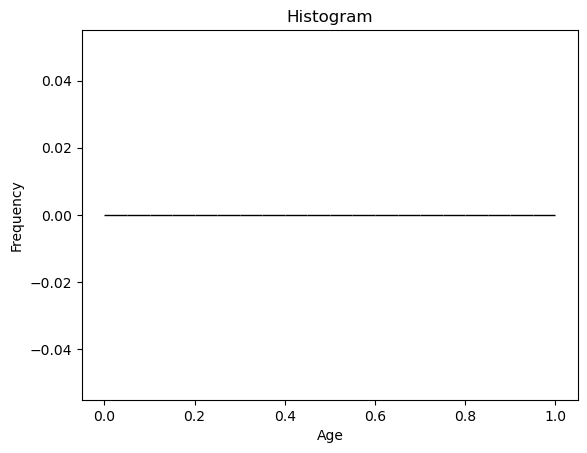

In [51]:
host_age_df = tags_df[(tags_df['tag'] == "sex") & (tags_df['project'] == "PRJEB5482")]
print(host_age_df)

values = pd.to_numeric(host_age_df['value'], errors='coerce')
invalid_mask = values.isna()
num_invalid = invalid_mask.sum()
print(f"Number of non-numeric values: {num_invalid}")
invalid_values = host_age_df.loc[invalid_mask, 'value'].value_counts()
print(invalid_values)

# Convert the 'value' column to numeric for plotting
host_age_df['value'] = values

# Plot a histogram of the 'value' column
plt.hist(host_age_df['value'].dropna(), bins=20, edgecolor='black')
plt.title('Histogram')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()